<a href="https://colab.research.google.com/github/nilum2002/EN3150-Pattern-Recognition/blob/main/Answers_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

230415H - Code Workigs for Pattern Recognition Assignment02

Q1 - Code workings

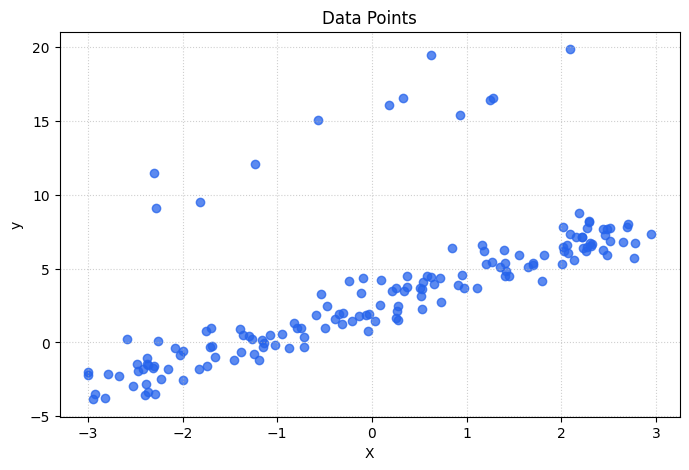

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


rng = np.random.default_rng(230415)
X = rng.uniform(-3, 3, size=(160, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 0.8, size=160)

# Add large errors to 12 observations.
outlier_idx = rng.choice(len(y), size=12, replace=False)
y[outlier_idx] += rng.uniform(10, 15, size=12)

# plot data points
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="#2563EB", alpha=0.75)
plt.title("Data Points")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [65]:
# split dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"Train data shape X : {X_train.shape}")
print(f"Test data shape X : {X_test.shape}")
print(f"Train data shape Y : {y_train.shape}")
print(f"Test data shape Y : {y_test.shape}")


# linear regression
regr = LinearRegression()
regr.fit(X_train, y_train)

# predictions
y_pred = regr.predict(X_test)


Train data shape X : (128, 1)
Test data shape X : (32, 1)
Train data shape Y : (128,)
Test data shape Y : (32,)


w_0 : 3.51
w_1 : 1.78
MSE Train : 11.65
MSE Test : 12.39


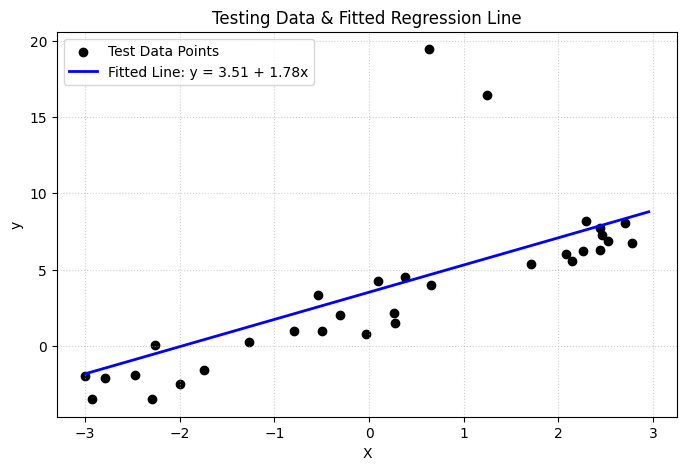

In [64]:
# interceptions
# w0, w, MSEtrain and MSEtest

w_1 = regr.coef_
w_0 = regr.intercept_

y_train_pred = regr.predict(X_train)
y_test_pred = regr.predict(X_test)
mse_train = mean_squared_error(y_train,y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"w_0 : {w_0:.2f}")
print(f"w_1 : {w_1[0]:.2f}")
print(f"MSE Train : {mse_train:.2f}")
print(f"MSE Test : {mse_test:.2f}")


# Plotting
plt.figure(figsize=(8, 5))

# Scatter actual test data points
plt.scatter(X_test, y_test, color="black", label="Test Data Points")

# Draw a smooth, continuous regression line
X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = regr.predict(X_line)
plt.plot(
    X_line,
    y_line,
    color="blue",
    linewidth=2,
    label=f"Fitted Line: y = {w_0:.2f} + {w_1[0]:.2f}x",
)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Testing Data & Fitted Regression Line")
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()